# 📚 Sistem Rekomendasi Buku Jaklitera
**Hybrid Content-Based Filtering & Semantic Search (2 Model)**

- **Model 1**: Item-to-Item Hybrid Content-Based Filtering (TF-IDF + Adaptive Weighting)
- **Model 2**: Semantic Search (IndoBERT/SBERT + TF-IDF Fallback)

## 1. Import Library & Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import re
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import scipy.sparse as sp
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')

# ─── Konfigurasi Path ───────────────────────────────────────────────────────
DATA_PATH = 'Dataset_Buku_Jaklitera_Clean.csv'  # ganti path jika berbeda
TOP_N     = 10   # jumlah rekomendasi default

print('✅ Library berhasil di-import')

C:\Users\farel\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Library berhasil di-import


## 2. Load & Eksplorasi Data

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape       : {df.shape}')
print(f'Kolom       : {df.columns.tolist()}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nDistribusi Kategori:')
print(df['Kategori_Asal'].value_counts())

df.head(3)

Shape       : (5005, 9)
Kolom       : ['Kategori_Asal', 'Judul', 'Penulis', 'Deskripsi', 'ISBN', 'Bahasa', 'Penerbit', 'Cover_URL', 'Local_Path']

Missing Values:
Kategori_Asal     0
Judul             3
Penulis           3
Deskripsi         0
ISBN             81
Bahasa            0
Penerbit          0
Cover_URL         0
Local_Path        0
dtype: int64

Distribusi Kategori:
Kategori_Asal
Fiksi                1120
Sejarah               640
komik                 639
Agama                 607
pengembangan diri     479
Ekonomi               320
Teknologi             319
Inspirasi             316
Administrasi          313
Humor                 252
Name: count, dtype: int64


,Kategori_Asal,Judul,Penulis,Deskripsi,ISBN,Bahasa,Penerbit,Cover_URL,Local_Path
0,Fiksi,Petualangan Tintin: Perjalanan ke Bulan,Herge (Pengarang) ; Anastasia Mustika W. (Pene...,Petualangan Tintin: Perjalanan Ke Bulan,9786020308470,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2024",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\petualangan_tintin_perjalanan_ke_bulan.jpg
1,Fiksi,A crane among wolves = bangau di tengah kawana...,"Hur, June (Pengarang) ; Meggy Soedjatmiko (Pen...","1506, Joseon. Rakyat hidup menderita karena ke...",9786020681399,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2025",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\a_crane_among_wolves_=_bangau_di_tengah...
2,Fiksi,Kokokan mencari arumbawangi,Cyntha Hariadi (Pengarang),"Seorang anak dikirim dari langit, dibawa oleh ...",9786020640259,Indonesia,"Jakarta : Gramedia Pustaka Utama, 2025",https://perpustakaan.jakarta.go.id/catalog-dis...,covers\kokokan_mencari_arumbawangi.jpg


=== 1. Memuat Dataset ===
Total Baris: 5005
Total Kolom: 9

=== 2. Informasi Struktur & Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Kategori_Asal  5005 non-null   object
 1   Judul          5002 non-null   object
 2   Penulis        5002 non-null   object
 3   Deskripsi      5005 non-null   object
 4   ISBN           4924 non-null   object
 5   Bahasa         5005 non-null   object
 6   Penerbit       5005 non-null   object
 7   Cover_URL      5005 non-null   object
 8   Local_Path     5005 non-null   object
dtypes: object(9)
memory usage: 352.0+ KB

Detail Jumlah Missing Values per Kolom:
Judul       3
Penulis     3
ISBN       81
dtype: int64


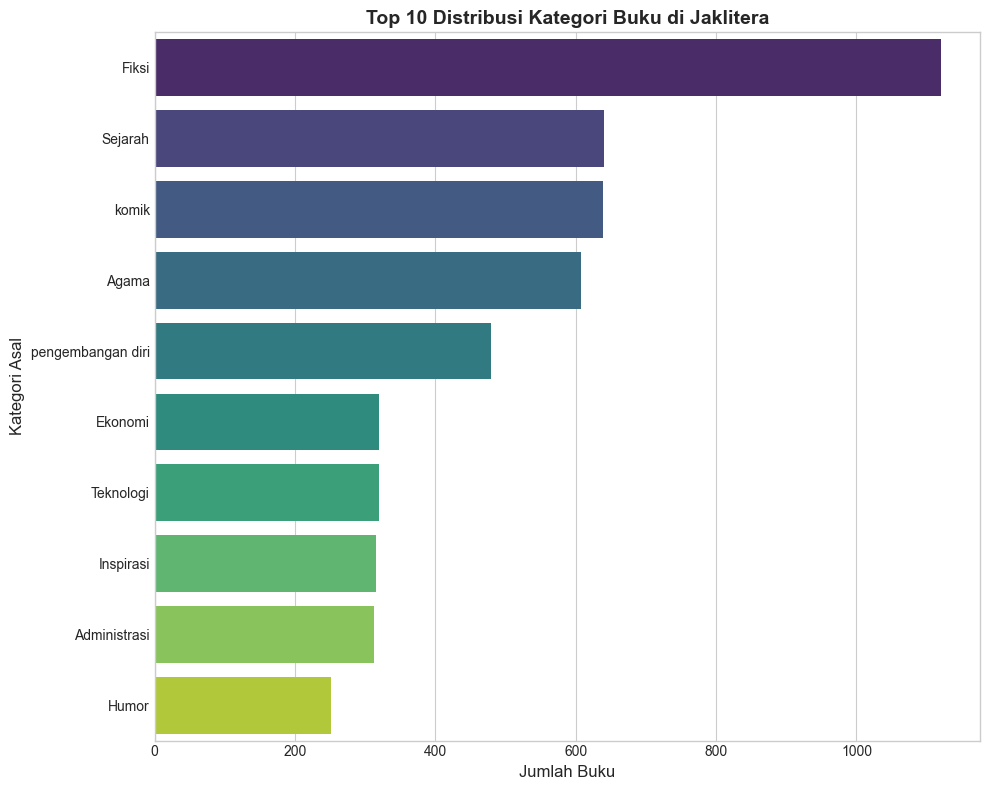


=== 3. Analisis Dimensi Teks Deskripsi ===
Statistik Deskriptif Jumlah Kata pada Sinopsis/Deskripsi:
count    5005.000000
mean       57.752647
std        63.906544
min         1.000000
25%         4.000000
50%        39.000000
75%        87.000000
max       558.000000
Name: jumlah_kata_deskripsi, dtype: float64


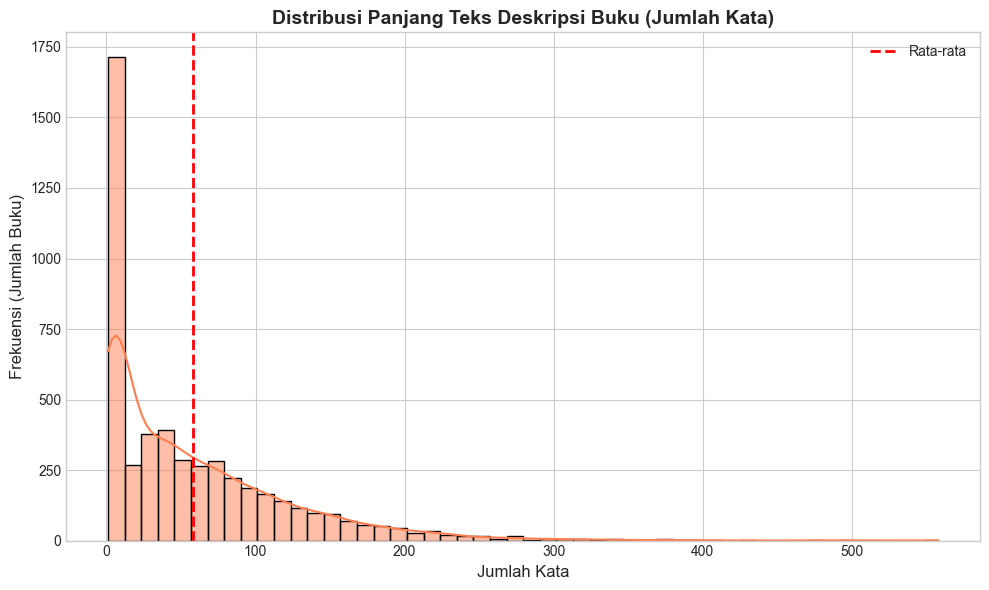


=== 4. Pengecekan Data Duplikat ===
Jumlah buku dengan Judul dan Penulis yang identik (Potensi Duplikat): 253


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mengatur gaya grafik agar terlihat profesional untuk skripsi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# ==========================================
# 1. MEMUAT DATASET
# ==========================================
print("=== 1. Memuat Dataset ===")
# Pastikan file CSV berada di folder yang sama dengan script/notebook ini
df = pd.read_csv('Dataset_Buku_Jaklitera_Clean.csv')
print(f"Total Baris: {df.shape[0]}")
print(f"Total Kolom: {df.shape[1]}\n")

# 2. PEMERIKSAAN TIPE DATA & MISSING VALUES

print("=== 2. Informasi Struktur & Missing Values ===")
# Melihat tipe data
df.info()

print("\nDetail Jumlah Missing Values per Kolom:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0]) # Hanya menampilkan kolom yang ada missing valuenya

# ==========================================
# 3. VISUALISASI DISTRIBUSI KATEGORI (Kategori_Asal)
# ==========================================
plt.figure(figsize=(10, 8))
# Mengambil 10 kategori terbanyak agar grafik tidak berantakan
top_categories = df['Kategori_Asal'].value_counts().head(10)

sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title('Top 10 Distribusi Kategori Buku di Jaklitera', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Buku', fontsize=12)
plt.ylabel('Kategori Asal', fontsize=12)
plt.tight_layout()
plt.show()
# Grafik ini membuktikan kepada penguji variasi genre yang ada di pangkalan data Anda

# ==========================================
# 4. ANALISIS PANJANG TEKS (Fundamental untuk TF-IDF & S-BERT)
# ==========================================
print("\n=== 3. Analisis Dimensi Teks Deskripsi ===")
# Membuat kolom baru yang berisi jumlah kata dari setiap deskripsi
df['jumlah_kata_deskripsi'] = df['Deskripsi'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

print("Statistik Deskriptif Jumlah Kata pada Sinopsis/Deskripsi:")
print(df['jumlah_kata_deskripsi'].describe())

# Visualisasi Distribusi Panjang Teks
plt.figure(figsize=(10, 6))
sns.histplot(df[df['jumlah_kata_deskripsi'] > 0]['jumlah_kata_deskripsi'], 
             bins=50, kde=True, color='coral')
plt.title('Distribusi Panjang Teks Deskripsi Buku (Jumlah Kata)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kata', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Buku)', fontsize=12)
# Menambahkan garis rata-rata
plt.axvline(df['jumlah_kata_deskripsi'].mean(), color='red', linestyle='dashed', linewidth=2, label='Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()
# Grafik ini sangat penting untuk membuktikan argumen "Dimensi Teks yang Heterogen" di Bab 4.1

# ==========================================
# 5. CEK DATA DUPLIKAT
# ==========================================
print("\n=== 4. Pengecekan Data Duplikat ===")
jumlah_duplikat = df.duplicated(subset=['Judul', 'Penulis']).sum()
print(f"Jumlah buku dengan Judul dan Penulis yang identik (Potensi Duplikat): {jumlah_duplikat}")

## 3. Preprocessing

In [5]:
def clean_text(text: str) -> str:
    """Membersihkan teks: lowercase, hapus karakter non-alfabet."""
    if pd.isna(text) or text.strip() == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_main_author(penulis: str) -> str:
    """Ambil nama penulis utama (sebelum tanda kurung atau titik koma)."""
    if pd.isna(penulis):
        return ''
    main = re.split(r'\s*[;(]', str(penulis))[0].strip()
    return clean_text(main)

# ─── Reset index & hapus baris tanpa Judul ──────────────────────────────────
df = df.dropna(subset=['Judul']).reset_index(drop=True)

# ─── Fitur bersih ───────────────────────────────────────────────────────────
df['judul_clean']     = df['Judul'].apply(clean_text)
df['deskripsi_clean'] = df['Deskripsi'].apply(clean_text)
df['penulis_clean']   = df['Penulis'].apply(extract_main_author)
df['kategori_clean']  = df['Kategori_Asal'].apply(clean_text)

# ─── Flag ketersediaan deskripsi ─────────────────────────────────────────────
df['has_desc'] = df['deskripsi_clean'].apply(lambda x: len(x) > 20)

print(f'Total buku        : {len(df)}')
print(f'Buku punya desc   : {df["has_desc"].sum()}')
print(f'Buku tanpa desc   : {(~df["has_desc"]).sum()}')

df[['Judul','judul_clean','penulis_clean','kategori_clean','has_desc']].head(5)

Total buku        : 5002
Buku punya desc   : 3494
Buku tanpa desc   : 1508


,Judul,judul_clean,penulis_clean,kategori_clean,has_desc
0,Petualangan Tintin: Perjalanan ke Bulan,petualangan tintin perjalanan ke bulan,herge,fiksi,True
1,A crane among wolves = bangau di tengah kawana...,a crane among wolves bangau di tengah kawanan ...,hur june,fiksi,True
2,Kokokan mencari arumbawangi,kokokan mencari arumbawangi,cyntha hariadi,fiksi,True
3,The necklace and other stories,the necklace and other stories,maupassant guy de,fiksi,True
4,Boneka sandya,boneka sandya,eve shi,fiksi,True


## 4. Bangun TF-IDF per Atribut (Untuk Model 1 & Fallback Model 2)

In [6]:
# ─── Vectorizer per atribut ──────────────────────────────────────────────────
tfidf_judul = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_desc = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    max_features=15000
)

tfidf_penulis = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=1
)

tfidf_kategori = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=1
)

# ─── Fit & transform ─────────────────────────────────────────────────────────
mat_judul    = tfidf_judul.fit_transform(df['judul_clean'])
mat_desc     = tfidf_desc.fit_transform(df['deskripsi_clean'])
mat_penulis  = tfidf_penulis.fit_transform(df['penulis_clean'])
mat_kategori = tfidf_kategori.fit_transform(df['kategori_clean'])

print('Shape matriks TF-IDF:')
print(f'  Judul    : {mat_judul.shape}')
print(f'  Deskripsi: {mat_desc.shape}')
print(f'  Penulis  : {mat_penulis.shape}')
print(f'  Kategori : {mat_kategori.shape}')

Shape matriks TF-IDF:
  Judul    : (5002, 27681)
  Deskripsi: (5002, 15000)
  Penulis  : (5002, 5040)
  Kategori : (5002, 11)


## 5. Model 1 (Item-to-Item) – Adaptive Weighted Ensemble

In [7]:
# ─── Bobot dasar ─────────────────────────────────────────────────────────────
BASE_WEIGHTS = {
    'judul'   : 0.40,
    'desc'    : 0.35,
    'penulis' : 0.15,
    'kategori': 0.10
}

def adaptive_weights(has_desc: bool) -> dict:
    if has_desc:
        return BASE_WEIGHTS.copy()
    fallback = {
        'judul'   : 0.60,
        'desc'    : 0.00,
        'penulis' : 0.25,
        'kategori': 0.15
    }
    return fallback

def build_hybrid_matrix_for_query(query_idx: int) -> np.ndarray:
    has_desc  = bool(df.loc[query_idx, 'has_desc'])
    w         = adaptive_weights(has_desc)

    sim_j = cosine_similarity(mat_judul[query_idx], mat_judul).flatten()
    sim_d = cosine_similarity(mat_desc[query_idx],  mat_desc).flatten()
    sim_p = cosine_similarity(mat_penulis[query_idx], mat_penulis).flatten()
    sim_k = cosine_similarity(mat_kategori[query_idx], mat_kategori).flatten()

    hybrid = (w['judul'] * sim_j + w['desc'] * sim_d + w['penulis'] * sim_p + w['kategori'] * sim_k)
    return hybrid

print('✅ Fungsi hybrid model siap')

✅ Fungsi hybrid model siap


## 6. Fungsi Rekomendasi Model 1

In [8]:
def find_book_idx(title: str) -> int | None:
    title_lower = title.lower().strip()
    exact = df[df['judul_clean'] == clean_text(title_lower)]
    if len(exact) > 0:
        return exact.index[0]
    partial = df[df['judul_clean'].str.contains(clean_text(title_lower), na=False)]
    if len(partial) > 0:
        return partial.index[0]
    return None

def recommend_v1(title: str, top_n: int = TOP_N, verbose: bool = True) -> pd.DataFrame:
    idx = find_book_idx(title)
    if idx is None:
        print(f'❌ Buku "{title}" tidak ditemukan dalam dataset.')
        return pd.DataFrame()

    query_book = df.loc[idx]
    has_desc   = bool(query_book['has_desc'])
    w          = adaptive_weights(has_desc)

    if verbose:
        print(f'📖 Buku query  : {query_book["Judul"]}')
        print(f'   Penulis    : {query_book["Penulis"]}')
        print(f'   Kategori   : {query_book["Kategori_Asal"]}')
        print(f'   Punya desc : {has_desc}')
        print('─' * 60)

    hybrid_scores = build_hybrid_matrix_for_query(idx)
    sorted_idx = np.argsort(hybrid_scores)[::-1]
    sorted_idx = [i for i in sorted_idx if i != idx][:top_n]

    results = df.loc[sorted_idx, ['Judul', 'Penulis', 'Kategori_Asal', 'Deskripsi']].copy()
    results['Skor'] = hybrid_scores[sorted_idx].round(4)
    results['Deskripsi_Singkat'] = results['Deskripsi'].apply(lambda x: str(x)[:120] + '...' if pd.notna(x) and len(str(x)) > 120 else str(x))
    results = results.drop(columns=['Deskripsi']).reset_index(drop=True)
    results.index += 1
    return results

print('✅ Fungsi rekomendasi M1 siap')

✅ Fungsi rekomendasi M1 siap


In [11]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. Tentukan Kueri Utama
query_title = 'laut bercerita'
# Mengambil indeks pertama yang cocok dengan kueri
idx_q = df[df['judul_clean'].str.contains(query_title, na=False)].index[0]
judul_q_asli = df.loc[idx_q, 'Judul']

# 2. Tentukan 4 Sampel Kandidat untuk Bab 4
kandidat_titles = [
    'nadira',
    'semesta bercerita',
    'biarkan waktu yang bercerita',
    'laut sebelum pasang'
]

# Siapkan penampung data
hasil_parsial = []

print(f" Kueri Acuan: {judul_q_asli}\n")

# 3. Lakukan Perhitungan Parsial untuk Setiap Kandidat
for title in kandidat_titles:
    # Cari indeks kandidat di dataset
    try:
        idx_c = df[df['judul_clean'].str.contains(title, na=False)].index[0]
        judul_c_asli = df.loc[idx_c, 'Judul']
    except IndexError:
        print(f" Peringatan: Buku dengan judul '{title}' tidak ditemukan.")
        continue
    
    # Hitung Cosine Similarity menggunakan fungsi scikit-learn
    # [0][0] digunakan untuk mengekstrak angka tunggal (skalar) dari matriks 2D
    sim_j = cosine_similarity(mat_judul[idx_q], mat_judul[idx_c])[0][0]
    sim_d = cosine_similarity(mat_desc[idx_q], mat_desc[idx_c])[0][0]
    sim_p = cosine_similarity(mat_penulis[idx_q], mat_penulis[idx_c])[0][0]
    sim_k = cosine_similarity(mat_kategori[idx_q], mat_kategori[idx_c])[0][0]
    
    # Simpan hasil komputasi
    hasil_parsial.append({
        'Kandidat Evaluasi': judul_c_asli,
        'Sim_Judul': sim_j,
        'Sim_Deskripsi': sim_d,
        'Sim_Penulis': sim_p,
        'Sim_Kategori': sim_k
    })

# 4. Ubah ke Format DataFrame agar tampil rapi sebagai Tabel
df_parsial = pd.DataFrame(hasil_parsial)

# Bulatkan angka menjadi 4 desimal sesuai standar penulisan skripsi
for col in ['Sim_Judul', 'Sim_Deskripsi', 'Sim_Penulis', 'Sim_Kategori']:
    df_parsial[col] = df_parsial[col].round(4)

print("=== MATRIKS COSINE SIMILARITY (4 KANDIDAT) ===")
# Jika menggunakan Jupyter/Colab, gunakan display(). Jika terminal biasa, gunakan print()
try:
    display(df_parsial)
except NameError:
    print(df_parsial.to_string(index=False))

 Kueri Acuan: Laut bercerita

=== MATRIKS COSINE SIMILARITY (4 KANDIDAT) ===


,Kandidat Evaluasi,Sim_Judul,Sim_Deskripsi,Sim_Penulis,Sim_Kategori
0,Nadira,0.0000,0.0454,1.0,1.0
1,Semesta bercerita,0.3373,0.0435,0.0,1.0
2,Biarkan waktu yang bercerita,0.2279,0.0572,0.0,1.0
3,Laut Sebelum Pasang,0.2062,0.0473,0.0,1.0


## 7. Demo Model 1 (Item-to-Item)

In [10]:
hasil_m1 = recommend_v1('laut bercerita')
display(hasil_m1)

📖 Buku query  : Laut bercerita
   Penulis    : Leila S. Chudori (Pengarang) ; Endah Sulwesi (Penyunting) ; Christina M. Udiani (Penyunting)
   Kategori   : Fiksi
   Punya desc : True
────────────────────────────────────────────────────────────


,Judul,Penulis,Kategori_Asal,Skor,Deskripsi_Singkat
1,Nadira,Leila S. Chudori (Pengarang),Fiksi,0.2659,"DI SEBUAH pagi yang murung, Nadira Suwandi men..."
2,Semesta bercerita,Astronotess (Pengarang) ; Aning (Penyunting),Fiksi,0.2501,Semesta Bercerita Apakah kamu pernah merasa di...
3,Biarkan waktu yang bercerita,Kiranti Dwi A. (Pengarang),Fiksi,0.2112,Dear Galang Rafandra Bagaimana kabarmu saat in...
4,Laut Sebelum Pasang,Lilpudu (Pengarang) ; Ikhwan Pahri (Penyunting...,Fiksi,0.1990,entang kebahagiaan sebelum peristiwa Tsunami 1...
5,A Moment To Love You,Robin Wijaya (Pengarang),Fiksi,0.1502,Kisah yang akan kau temui di sini; memang buka...
6,To your summit,Nabilla Rutami (Pengarang) ; Nomena Titi Sandr...,Fiksi,0.1415,Diaz Naratama Putra Mahakam asing dengan kata ...
7,"Dear, imamku",Mellyana (Pengarang) ; Uly Amalia (Penyunting),Fiksi,0.1395,"Haris, seorang dokter tampan yang menikahi gad..."
8,Second hope,Flara Deviana (Pengarang),Fiksi,0.1390,Nora Alexander memiliki segalanya. Keluarga be...
9,Altop,Tasya_02 (Pengarang) ; Pricilia AW (Penyunting...,Fiksi,0.1390,"Altopan Lioner, lahir dan tumbuh dari keluarga..."
10,The story puppy,"Webb, Holly (Pengarang) ; Williams, Sophy (Ilu...",Fiksi,0.1369,"Jack kesulitan membaca di sekolah, hingga ia b..."


## 8. Model 2 (Semantic Search) – IndoBERT + TF-IDF Fallback
Model 2 akan menerima teks bebas (cerita), melakukan *encoding* dengan SBERT, dan menggabungkannya dengan fallback TF-IDF untuk buku yang tidak memiliki deskripsi. Memanfaatkan fungsi prapemrosesan dan matriks dari Model 1 secara langsung.

In [13]:
from sentence_transformers import SentenceTransformer, CrossEncoder

In [14]:
class BookRecommenderV2_Rich:
    def __init__(self, dataset):
        print('Inisialisasi Model 2 (Semantic Search - Rich Representation)...')
        self.df = dataset.copy()
        self.has_desc_mask = self.df['has_desc']
        
        print('Memuat model Multilingual SBERT...')
        start_time = time.time()
        # Menggunakan Multilingual SBERT untuk mengatasi deskripsi berbahasa asing (Inggris/Indonesia)
        self.sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2') 
        print(f'SBERT berhasil dimuat dalam {time.time() - start_time:.2f} detik')
        
        print('Membangun Rich Semantic Embeddings...')
        valid_books = self.df[self.has_desc_mask]
        
        # --- EARLY FUSION (RICH DOCUMENT REPRESENTATION) ---
        # Melebur semua metadata menjadi satu kesatuan teks yang kaya makna
        rich_texts = (
            "kategori: " + valid_books['kategori_clean'] + ". " + 
            "penulis: " + valid_books['penulis_clean'] + ". " +
            "judul: " + valid_books['judul_clean'] + ". " + 
            "cerita: " + valid_books['deskripsi_clean']
        ).tolist()
        
        # Melakukan encoding pada teks gabungan
        self.sbert_embeddings = self.sbert.encode(rich_texts, show_progress_bar=True)
        print('Model 2 (Rich Representation) siap digunakan!\n')

    def recommend(self, story_query, top_n=10):
        # Bersihkan input pengguna
        cleaned_query = clean_text(story_query)

        # 1. Transformasi Kueri (Hanya Teks Bebas)
        query_embedding = self.sbert.encode([cleaned_query])
        
        # Transformasi Fallback TF-IDF
        query_tfidf_desc = tfidf_desc.transform([cleaned_query])
        query_tfidf_judul = tfidf_judul.transform([cleaned_query])
        query_tfidf_kategori = tfidf_kategori.transform([cleaned_query])

        # 2. Perhitungan Similaritas Base
        sim_sbert = np.zeros(len(self.df))
        # SBERT mencocokkan kueri cerita dengan vektor metadata gabungan di database
        sim_sbert[self.has_desc_mask] = cosine_similarity(query_embedding, self.sbert_embeddings).flatten()
        
        # Similaritas TF-IDF (Fallback)
        sim_tfidf_desc = cosine_similarity(query_tfidf_desc, mat_desc).flatten()
        sim_tfidf_judul = cosine_similarity(query_tfidf_judul, mat_judul).flatten()
        sim_tfidf_kategori = cosine_similarity(query_tfidf_kategori, mat_kategori).flatten()
        
        sim_tfidf_fallback = (sim_tfidf_judul + sim_tfidf_kategori) / 2.0

        # 3. Penggabungan Skor (Skema Bobot Asli)
        final_scores = np.zeros(len(self.df))
        
        for i in range(len(self.df)):
            if self.has_desc_mask.iloc[i]:
                # 70% SBERT (Rich) + 30% TF-IDF Deskripsi
                final_scores[i] = (0.7 * sim_sbert[i]) + (0.3 * sim_tfidf_desc[i])
            else:
                # 100% Fallback (Penalti 0.6) untuk buku tanpa deskripsi
                final_scores[i] = sim_tfidf_fallback[i] * 0.6

        # 4. Sorting & Formatting
        top_indices = final_scores.argsort()[::-1][:top_n]
        
        results = self.df.iloc[top_indices].copy()
        results['Final_Score'] = final_scores[top_indices].round(4)
        
        results = results.reset_index(drop=True)
        results.index += 1
        
        return results[['Judul', 'Penulis', 'Kategori_Asal', 'Final_Score']]

# Instansiasi Model
model2_rich = BookRecommenderV2_Rich(df)

Inisialisasi Model 2 (Semantic Search - Rich Representation)...
Memuat model Multilingual SBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3281.54it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT berhasil dimuat dalam 8.24 detik
Membangun Rich Semantic Embeddings...


Batches: 100%|██████████| 110/110 [00:49<00:00,  2.20it/s]

Model 2 (Rich Representation) siap digunakan!



## 9. Demo Model 2 (Semantic Search)

In [16]:
teks_bebas = "sekumpulan anak-anak sekolah yang bertualang memecahkan teka-teki misteri di sebuah pulau terpencil yang berbahaya."
print(f'🔍 Query: "{teks_bebas}"\n')

hasil_m2 = model2_rich.recommend(teks_bebas, top_n=5)
display(hasil_m2)

🔍 Query: "sekumpulan anak-anak sekolah yang bertualang memecahkan teka-teki misteri di sebuah pulau terpencil yang berbahaya."



,Judul,Penulis,Kategori_Asal,Final_Score
1,The mysterious island = pulau misterius,Verne Jules (Pengarang) ; Femmy Syahrani (Pene...,Fiksi,0.5136
2,The sorcery little magacal piya,Cindyana H (Pengarang) ; Dana Sudartoyo (Penyu...,Fiksi,0.4791
3,Seri misteri favorit : misteri pulau betuah,Tuti Sitanggang (Pengarang) ; Pradikha Bestari...,Fiksi,0.4719
4,Si Juki the movie : Harta pulau monyet,Faza Meonk (Pengarang),Fiksi,0.4629
5,Si Juki the movie : Harta pulau monyet,Faza Meonk (Pengarang),komik,0.4600


In [ ]:
teks_bebas = ""
print(f'🔍 Query: "{teks_bebas}"\n')

hasil_m2 = model2_rich.recommend(teks_bebas, top_n=5)
display(hasil_m2)

🔍 Query: "cerita kasus pembunuhan di sebuah pulau terpencil yang penuh misteri."



,Judul,Penulis,Kategori_Asal,Deskripsi,Final_Score,SBERT_Score,TFIDF_Fallback_Score
1,Q.E.D. Iff Vol.13,Katou Motohiro (Pengarang) ; Faira Amadea (Pen...,komik,TKP PEMBUNUHAN Sebuah kasus pembunuhan misteri...,0.5385,0.6710,0.0000
2,Black showman dan pembunuhan di kota tak bernama,Higashino Keigo (Pengarang) ; Juliana Tan (Pen...,Fiksi,“Black Showman dan Pembunuhan di Kota Tak Bern...,0.5236,0.6816,0.1091
3,Dunia yatim piatu,Giuseppe Caputo (Pengarang) ; Putu Juli Sastra...,Fiksi,Dunia yatim piatu bercerita tentang hubungan b...,0.4858,0.6388,0.0000
4,Laut bercerita,Leila S. Chudori (Pengarang) ; Endah Sulwesi (...,Fiksi,"Laut Bercerita, novel terbaru Leila S. Chudori...",0.4808,0.6805,0.0000
5,Jujutsu kaisen 15,"Akutami, Gege (Pengarang) ; Mustika Maria (Pen...",komik,"Pembunuhan massal oleh Sukuna, kematian Nanami...",0.4534,0.6216,0.0000


## 10. Evaluasi Model 1 (Catalog-based)

In [17]:
def get_rec_indices(query_idx: int, top_n: int = TOP_N) -> list[int]:
    scores     = build_hybrid_matrix_for_query(query_idx)
    sorted_idx = np.argsort(scores)[::-1]
    return [i for i in sorted_idx if i != query_idx][:top_n]

def precision_at_k(query_idx: int, k: int = TOP_N) -> float:
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)
    relevant  = sum(1 for i in recs if df.loc[i, 'Kategori_Asal'] == query_cat)
    return relevant / k if k > 0 else 0.0

def mrr(query_idx: int, k: int = TOP_N) -> float:
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)
    for rank, i in enumerate(recs, start=1):
        if df.loc[i, 'Kategori_Asal'] == query_cat:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(query_idx: int, k: int = TOP_N) -> float:
    query_cat = df.loc[query_idx, 'Kategori_Asal']
    recs      = get_rec_indices(query_idx, k)
    dcg  = sum((1 if df.loc[i, 'Kategori_Asal'] == query_cat else 0) / np.log2(rank + 1) for rank, i in enumerate(recs, start=1))
    n_relevant = sum(1 for i in recs if df.loc[i, 'Kategori_Asal'] == query_cat)
    idcg = sum(1 / np.log2(r + 1) for r in range(1, n_relevant + 1))
    return dcg / idcg if idcg > 0 else 0.0

In [18]:
def catalog_coverage(sample_indices: list[int], k: int = TOP_N) -> float:
    recommended = set()
    for idx in sample_indices:
        recommended.update(get_rec_indices(idx, k))
    return len(recommended) / len(df)

def intra_list_diversity(query_idx: int, k: int = TOP_N) -> float:
    recs = get_rec_indices(query_idx, k)
    if len(recs) < 2:
        return 0.0
    sub_j = mat_judul[recs]
    sub_d = mat_desc[recs]
    sub   = sp.hstack([sub_j, sub_d])
    sub_n = normalize(sub)
    sim_matrix = (sub_n @ sub_n.T).toarray()
    n = len(recs)
    pairs = [(sim_matrix[i, j]) for i in range(n) for j in range(i+1, n)]
    return float(np.mean(1 - np.array(pairs))) if pairs else 0.0

def novelty_score(sample_indices: list[int], k: int = TOP_N) -> float:
    from collections import Counter
    rec_counter: Counter = Counter()
    for idx in sample_indices:
        rec_counter.update(get_rec_indices(idx, k))
    total = sum(rec_counter.values())
    novelties = [-np.log2(count / total) for count in rec_counter.values()]
    return float(np.mean(novelties)) if novelties else 0.0

In [19]:
np.random.seed(42)
EVAL_SAMPLE = 200
sample_idx  = np.random.choice(df.index, size=EVAL_SAMPLE, replace=False).tolist()

print(f'🔍 Evaluasi pada {EVAL_SAMPLE} buku sampel (k={TOP_N})...')

prec_scores = [precision_at_k(i, TOP_N) for i in sample_idx]
mrr_scores  = [mrr(i, TOP_N)            for i in sample_idx]
ndcg_scores = [ndcg_at_k(i, TOP_N)      for i in sample_idx]
div_scores  = [intra_list_diversity(i, TOP_N) for i in sample_idx]
cov   = catalog_coverage(sample_idx, TOP_N)
nov   = novelty_score(sample_idx, TOP_N)

print('\n' + '═'*45)
print('         📊 HASIL EVALUASI MODEL 1')
print('═'*45)
print(f'  Precision@{TOP_N}   : {np.mean(prec_scores):.4f}')
print(f'  MRR@{TOP_N}         : {np.mean(mrr_scores):.4f}')
print(f'  NDCG@{TOP_N}        : {np.mean(ndcg_scores):.4f}')
print(f'  Coverage       : {cov:.4f}  ({cov*100:.1f}% katalog)')
print(f'  Diversity      : {np.mean(div_scores):.4f}')
print(f'  Novelty        : {nov:.4f}')
print('═'*45)

🔍 Evaluasi pada 200 buku sampel (k=10)...

═════════════════════════════════════════════
         📊 HASIL EVALUASI MODEL 1
═════════════════════════════════════════════
  Precision@10   : 0.9670
  MRR@10         : 0.9812
  NDCG@10        : 0.9864
  Coverage       : 0.3067  (30.7% katalog)
  Diversity      : 0.8507
  Novelty        : 10.6903
═════════════════════════════════════════════


## 11. Visualisasi Evaluasi Model 1

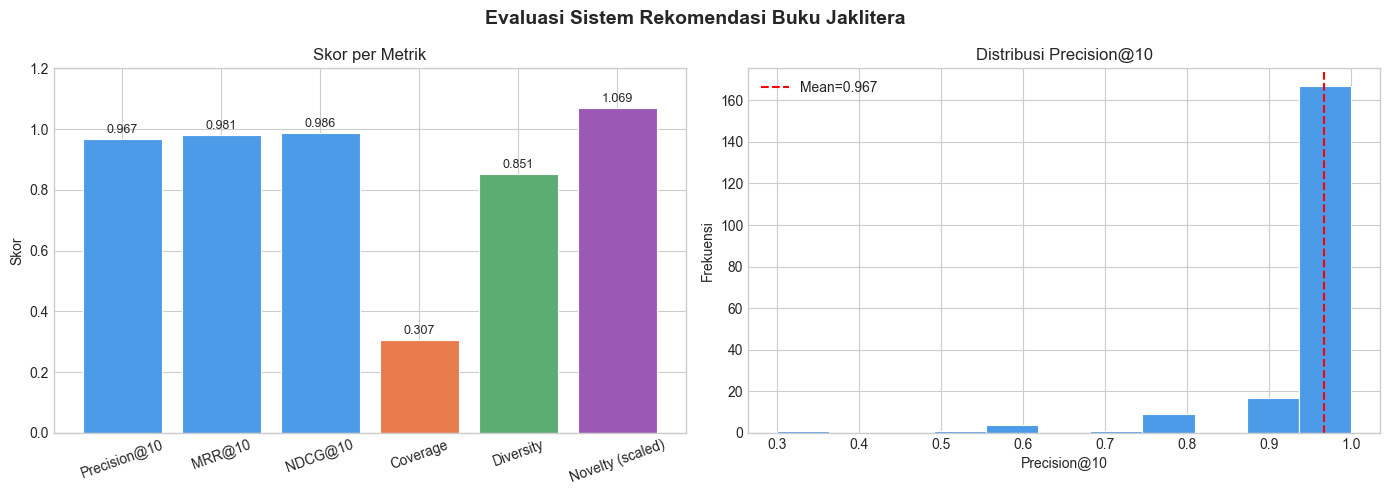

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

metrics = {
    f'Precision@{TOP_N}': np.mean(prec_scores),
    f'MRR@{TOP_N}'      : np.mean(mrr_scores),
    f'NDCG@{TOP_N}'     : np.mean(ndcg_scores),
    'Coverage'          : cov,
    'Diversity'         : np.mean(div_scores),
    'Novelty (scaled)'  : nov / 10
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Sistem Rekomendasi Buku Jaklitera', fontsize=14, fontweight='bold')

ax1 = axes[0]
colors = ['#4C9BE8', '#4C9BE8', '#4C9BE8', '#E87B4C', '#5BAD72', '#9B59B6']
bars   = ax1.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', linewidth=0.8)
ax1.set_ylim(0, 1.20)
ax1.set_ylabel('Skor')
ax1.set_title('Skor per Metrik')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, metrics.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
ax2.hist(prec_scores, bins=11, color='#4C9BE8', edgecolor='white', linewidth=0.8)
ax2.axvline(np.mean(prec_scores), color='red', linestyle='--', label=f'Mean={np.mean(prec_scores):.3f}')
ax2.set_xlabel(f'Precision@{TOP_N}')
ax2.set_ylabel('Frekuensi')
ax2.set_title(f'Distribusi Precision@{TOP_N}')
ax2.legend()

plt.tight_layout()
plt.show()

Evaluasi Model 2 (Semantic Search)

In [23]:
def evaluate_model2_fair(model, n_samples=200, k=TOP_N):
    np.random.seed(42)
    sample_df = df[df['has_desc'] == True].sample(n=n_samples, random_state=42)
    
    prec_scores, mrr_scores, ndcg_scores = [], [], []
    
    print(f"🔍 Evaluasi Model 2 (Fair) pada {n_samples} kueri murni...")
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        # --- KUERI MURNI (TANPA LEAKAGE) ---
        # Hanya menggunakan teks deskripsi cerita
        query_text = row['deskripsi_clean']
        
        true_cat = row['Kategori_Asal']
        true_title = row['Judul']
        
        # Dapatkan rekomendasi (top k+1 untuk memfilter buku asli)
        recs = model.recommend(query_text, top_n=k+1)
        recs = recs[recs['Judul'] != true_title].head(k)
        
        rec_cats = recs['Kategori_Asal'].tolist()
        
        # 1. Precision@K
        relevant_count = sum(1 for cat in rec_cats if cat == true_cat)
        prec_scores.append(relevant_count / k if k > 0 else 0)
        
        # 2. MRR
        mrr = 0.0
        for rank, cat in enumerate(rec_cats, start=1):
            if cat == true_cat:
                mrr = 1.0 / rank
                break
        mrr_scores.append(mrr)
        
        # 3. NDCG@K
        dcg = sum((1 if cat == true_cat else 0) / np.log2(rank + 1) for rank, cat in enumerate(rec_cats, start=1))
        idcg = sum(1 / np.log2(rank + 1) for rank in range(1, relevant_count + 1))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            
    print('\n' + '═'*45)
    print('HASIL EVALUASI MODEL 2 ')
    print('═'*45)
    print(f'  Precision@{k}   : {np.mean(prec_scores):.4f}')
    print(f'  MRR@{k}         : {np.mean(mrr_scores):.4f}')
    print(f'  NDCG@{k}        : {np.mean(ndcg_scores):.4f}')
    print('═'*45)
    
    # UBAH BAGIAN RETURN INI: Kembalikan ketiga rata-rata skornya
    return np.mean(prec_scores), np.mean(mrr_scores), np.mean(ndcg_scores)

# Tangkap ketiga nilainya ke dalam variabel baru
mean_prec_m2, mean_mrr_m2, mean_ndcg_m2 = evaluate_model2_fair(model2_rich, n_samples=200)

🔍 Evaluasi Model 2 (Fair) pada 200 kueri murni...

═════════════════════════════════════════════
HASIL EVALUASI MODEL 2 
═════════════════════════════════════════════
  Precision@10   : 0.5410
  MRR@10         : 0.7164
  NDCG@10        : 0.7504
═════════════════════════════════════════════


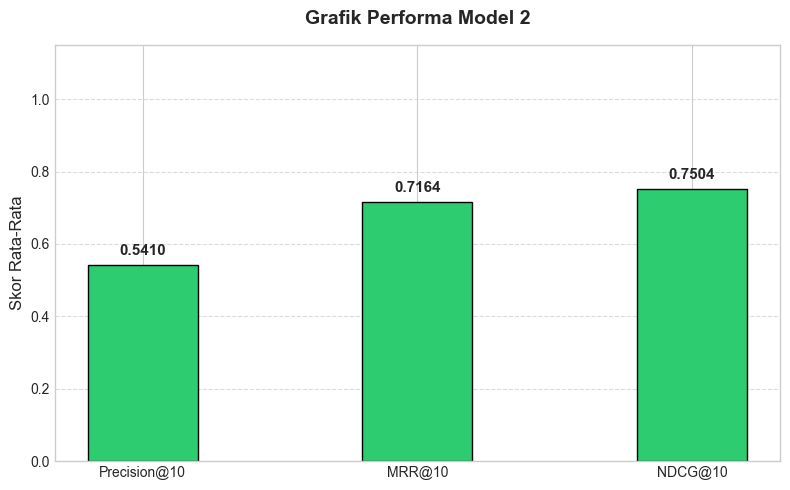

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. PASTIKAN EVALUASI MODEL 2 SUDAH DIJALANKAN
# Jika sudah ada di memori, baris ini bisa dilewati. Jika belum, hilangkan tanda pagarnya:
# mean_prec_m2, mean_mrr_m2, mean_ndcg_m2 = evaluate_model2_fair(model2_rich, n_samples=100)
# ==============================================================================

def visualize_model2_only(prec, mrr, ndcg, top_n=10):
    # Definisi label dan data
    metrik = [f'Precision@{top_n}', f'MRR@{top_n}', f'NDCG@{top_n}']
    skor = [prec, mrr, ndcg]
    
    # Pengaturan ukuran canvas
    plt.figure(figsize=(8, 5))
    
    # Pembuatan grafik batang (Bar Chart)
    bars = plt.bar(metrik, skor, color='#2ecc71', width=0.4, edgecolor='black')
    
    # Kustomisasi judul dan sumbu
    plt.title('Grafik Performa Model 2', 
              fontsize=14, fontweight='bold', pad=15)
    plt.ylim(0, 1.15) # Batas atas sumbu Y ditinggikan agar angka tidak terpotong
    plt.ylabel('Skor Rata-Rata', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Anotasi angka desimal (4 angka di belakang koma) di atas setiap batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 2. PANGGIL FUNGSI VISUALISASI
# Gunakan variabel TOP_N yang sudah ada di notebook Anda (misal: 10)
# ==============================================================================
visualize_model2_only(mean_prec_m2, mean_mrr_m2, mean_ndcg_m2, top_n=TOP_N)

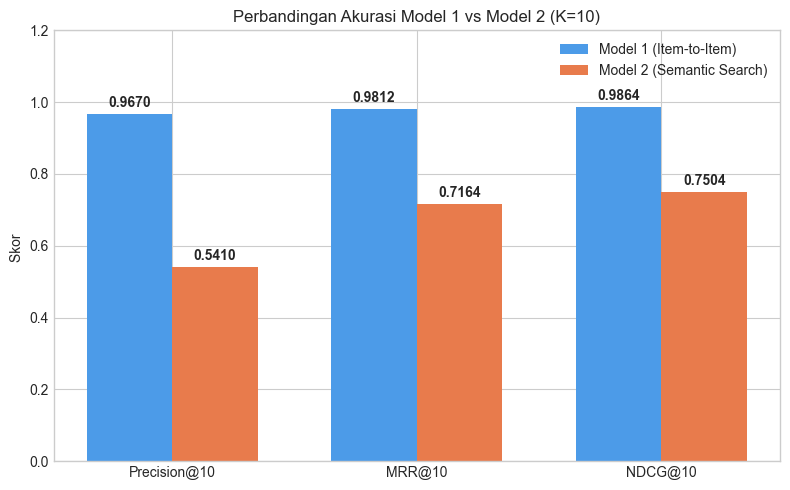

In [25]:
import matplotlib.pyplot as plt

# Tambahkan parameter m1_means dan m2_means pada fungsi
def compare_models(m1_means, m2_means, top_n=10):
    labels = [f'Precision@{top_n}', f'MRR@{top_n}', f'NDCG@{top_n}']
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, m1_means, width, label='Model 1 (Item-to-Item)', color='#4C9BE8')
    rects2 = ax.bar(x + width/2, m2_means, width, label='Model 2 (Semantic Search)', color='#E87B4C')
    
    ax.set_ylabel('Skor ')
    ax.set_title(f'Perbandingan Akurasi Model 1 vs Model 2 (K={top_n})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.20) # Ditinggikan sedikit menjadi 1.15 agar angka tidak terpotong garis atas
    
    # Anotasi value di atas bar (diubah menjadi 4 desimal agar akurat)
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. CARA MENJALANKAN GRAFIK
# ==========================================
# Ambil rata-rata Model 1 dari list komputasi sebelumnya
mean_prec_m1 = np.mean(prec_scores)
mean_mrr_m1  = np.mean(mrr_scores)
mean_ndcg_m1 = np.mean(ndcg_scores)

# Susun ke dalam array
m1_means_array = [mean_prec_m1, mean_mrr_m1, mean_ndcg_m1]
m2_means_array = [mean_prec_m2, mean_mrr_m2, mean_ndcg_m2]

# Panggil fungsi grafiknya
compare_models(m1_means_array, m2_means_array, top_n=TOP_N)

## 12. Analisis Sensitivitas Bobot

In [18]:
from itertools import product as iproduct

def evaluate_weights(wj, wd, wp, wk, sample=100):
    np.random.seed(0)
    idx_sample = np.random.choice(df.index, sample, replace=False)
    scores = []
    for idx in idx_sample:
        sim_j = cosine_similarity(mat_judul[idx],    mat_judul).flatten()
        sim_d = cosine_similarity(mat_desc[idx],     mat_desc).flatten()
        sim_p = cosine_similarity(mat_penulis[idx],  mat_penulis).flatten()
        sim_k = cosine_similarity(mat_kategori[idx], mat_kategori).flatten()
        hybrid   = wj*sim_j + wd*sim_d + wp*sim_p + wk*sim_k
        sorted_i = np.argsort(hybrid)[::-1]
        recs     = [i for i in sorted_i if i != idx][:TOP_N]
        q_cat    = df.loc[idx, 'Kategori_Asal']
        prec     = sum(1 for r in recs if df.loc[r, 'Kategori_Asal'] == q_cat) / TOP_N
        scores.append(prec)
    return np.mean(scores)

results_grid = []
for wj in [0.3, 0.4, 0.5, 0.6]:
    for wd in [0.2, 0.3, 0.4]:
        wp = 0.15
        wk = max(0.0, 1.0 - wj - wd - wp)
        if wk < 0:
            continue
        p = evaluate_weights(wj, wd, wp, wk, sample=80)
        results_grid.append({'w_judul': wj, 'w_desc': wd, 'w_penulis': wp,
                              'w_kategori': round(wk,2), 'precision': round(p,4)})

grid_df = pd.DataFrame(results_grid).sort_values('precision', ascending=False)
print('Top 5 kombinasi bobot:')
print(grid_df.head())

Top 5 kombinasi bobot:
   w_judul  w_desc  w_penulis  w_kategori  precision
0      0.3     0.2       0.15        0.35     0.9925
1      0.3     0.3       0.15        0.25     0.9875
2      0.3     0.4       0.15        0.15     0.9875
3      0.4     0.2       0.15        0.25     0.9862
4      0.4     0.3       0.15        0.15     0.9850


In [52]:
import joblib

print("Menyimpan artefak model ke dalam file...")

# 1. Simpan dataset yang sudah di-preprocess
df.to_pickle('dataset_jaklitera_processed.pkl')

# 2. Simpan komponen TF-IDF (Model 1 & Fallback Model 2)
tfidf_artifacts = {
    'vec_judul': tfidf_judul,
    'vec_desc': tfidf_desc,
    'vec_kategori': tfidf_kategori,
    'vec_penulis': tfidf_penulis,
    'mat_judul': mat_judul,
    'mat_desc': mat_desc,
    'mat_kategori': mat_kategori,
    'mat_penulis': mat_penulis
}
joblib.dump(tfidf_artifacts, 'tfidf_artifacts.joblib')

# 3. Simpan SBERT Embeddings (Hanya array vektornya saja)
joblib.dump(model2_rich.sbert_embeddings, 'sbert_embeddings.joblib')

print("✅ Ekspor selesai! File siap digunakan untuk API.")

Menyimpan artefak model ke dalam file...
✅ Ekspor selesai! File siap digunakan untuk API.
